                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

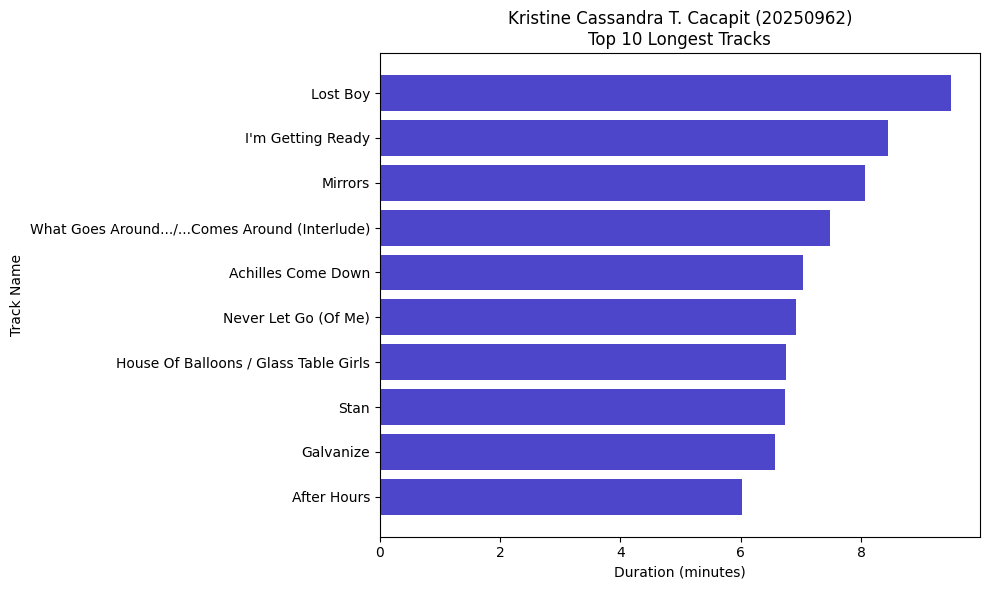

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = r"C:\Users\KC\Documents\Activity 7\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")

student_name = "Kristine Cassandra T. Cacapit" 
student_id = "20250962"

id_num = int(student_id[-3:])
color_bar = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}" 

df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')

clean_df = df[['track_name', 'artist', 'duration_min']].dropna()

top10 = clean_df.sort_values(by='duration_min', ascending=False).head(10)

print(top10)

plt.figure(figsize=(10, 6))
plt.barh(top10['track_name'], top10['duration_min'], color=color_bar)
plt.xlabel("Duration (minutes)")
plt.ylabel("Track Name")
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Tracks")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

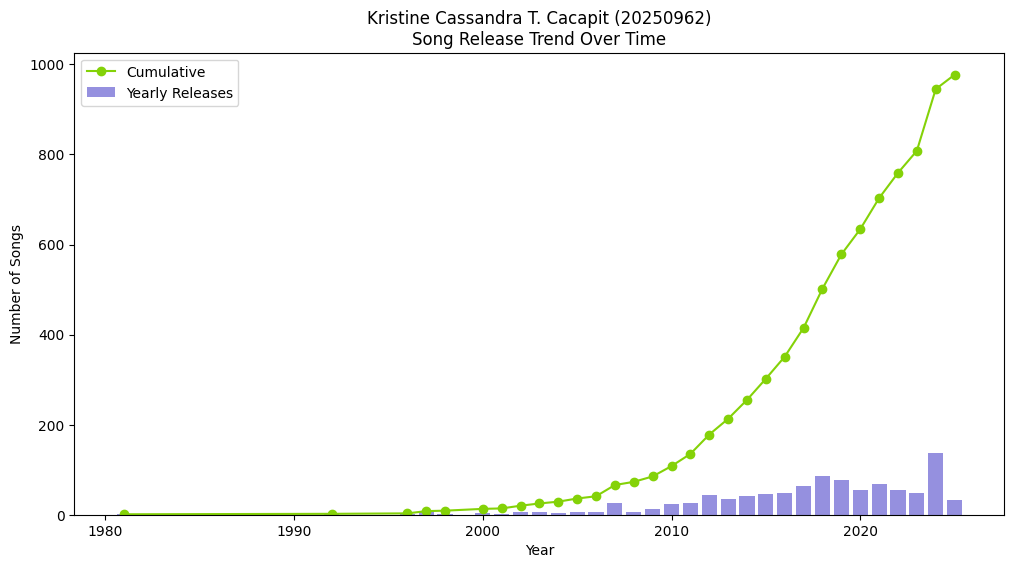

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = r"C:\Users\KC\Documents\Activity 7\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")

student_name = "Kristine Cassandra T. Cacapit" 
student_id = "20250962"

id_num = int(student_id[-3:]) 
color_bar = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}" 
color_line = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}" 

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

yearly = df.groupby('year').size().sort_index()

cumulative = yearly.cumsum()

plt.figure(figsize=(12, 6))
plt.bar(yearly.index, yearly.values, color=color_bar, alpha=0.6, label="Yearly Releases")
plt.plot(yearly.index, cumulative.values, color=color_line, marker='o', label="Cumulative")
plt.title(f"{student_name} ({student_id})\nSong Release Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.legend()
plt.show()

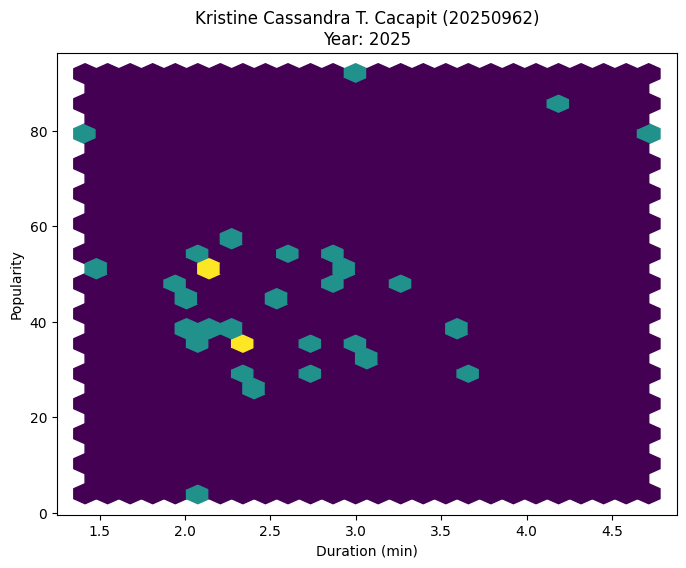

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

dataset_path = r"C:\Users\KC\Documents\Activity 7\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")

student_name = "Kristine Cassandra T. Cacapit" 
student_id = "20250962"

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

df = df.dropna(subset=['year', 'duration_min', 'popularity'])

years = sorted(df['year'].dropna().unique())

fig, ax = plt.subplots(figsize=(8, 6))

def update(year):
    ax.clear()
    data = df[df['year'] == year]

    ax.hexbin(
        data['duration_min'],
        data['popularity'],
        gridsize=25,
        cmap='viridis'
    )

    ax.set_title(f"{student_name} ({student_id})\nYear: {int(year)}")
    ax.set_xlabel("Duration (min)")
    ax.set_ylabel("Popularity")

ani = animation.FuncAnimation(fig, update, frames=years, interval=800)
ani.save(f"{student_name.replace(' ', '_')}_animation.gif", writer='pillow', fps=2)
plt.show()